In [72]:
import pandas as pd
# zss_1=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/zss1_m_config_score.csv')
# zss_2=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/zss2_m_config_score.csv')
adt=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/adt_m_tabular_score.csv')
# m_g=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/m_config_score.csv')

In [73]:
adt

,participantId,task_id,score,score_z,format
0,66475d6f7b27e4443ef0d031,1,0.993490,0.392222,json
1,67e571bef6af7ecd9c29ad72,1,0.993490,0.392222,json
2,60f1f1d4ac991a259b83f603,1,0.996094,0.400819,json
3,673c13c9d37c8a73bc80b8ce,1,0.998698,0.409415,json
4,667ac09492ea0caadf488520,1,0.481771,-1.296994,json
...,...,...,...,...,...
423,66bb6b7e0ccbed81f3ed30a8,4,0.950685,1.388909,xml
424,6753746b1f8827e2bd586bf0,4,0.960140,1.412020,xml
425,669a84e18da4349ece0ea67c,4,0.725342,0.838097,xml
426,67ab57e88fd0774428bd1f32,4,0.705662,0.789991,xml


In [74]:
adt
adt['task_id'] = adt['task_id'].replace({
    1: 'modifying-task-1',
    2: 'modifying-task-2',
    3: 'modifying-task-3',
    4: 'modifying-task-4',
})
adt

# m_g
# m_g['task'] = m_g['task'].replace({
#     'm_c_1': 'modifying-task-1',
#     'm_c_2': 'modifying-task-2',
#     'm_c_3': 'modifying-task-3',
#     'm_c_4': 'modifying-task-4',
# })
# m_g


,participantId,task_id,score,score_z,format
0,66475d6f7b27e4443ef0d031,modifying-task-1,0.993490,0.392222,json
1,67e571bef6af7ecd9c29ad72,modifying-task-1,0.993490,0.392222,json
2,60f1f1d4ac991a259b83f603,modifying-task-1,0.996094,0.400819,json
3,673c13c9d37c8a73bc80b8ce,modifying-task-1,0.998698,0.409415,json
4,667ac09492ea0caadf488520,modifying-task-1,0.481771,-1.296994,json
...,...,...,...,...,...
423,66bb6b7e0ccbed81f3ed30a8,modifying-task-4,0.950685,1.388909,xml
424,6753746b1f8827e2bd586bf0,modifying-task-4,0.960140,1.412020,xml
425,669a84e18da4349ece0ea67c,modifying-task-4,0.725342,0.838097,xml
426,67ab57e88fd0774428bd1f32,modifying-task-4,0.705662,0.789991,xml


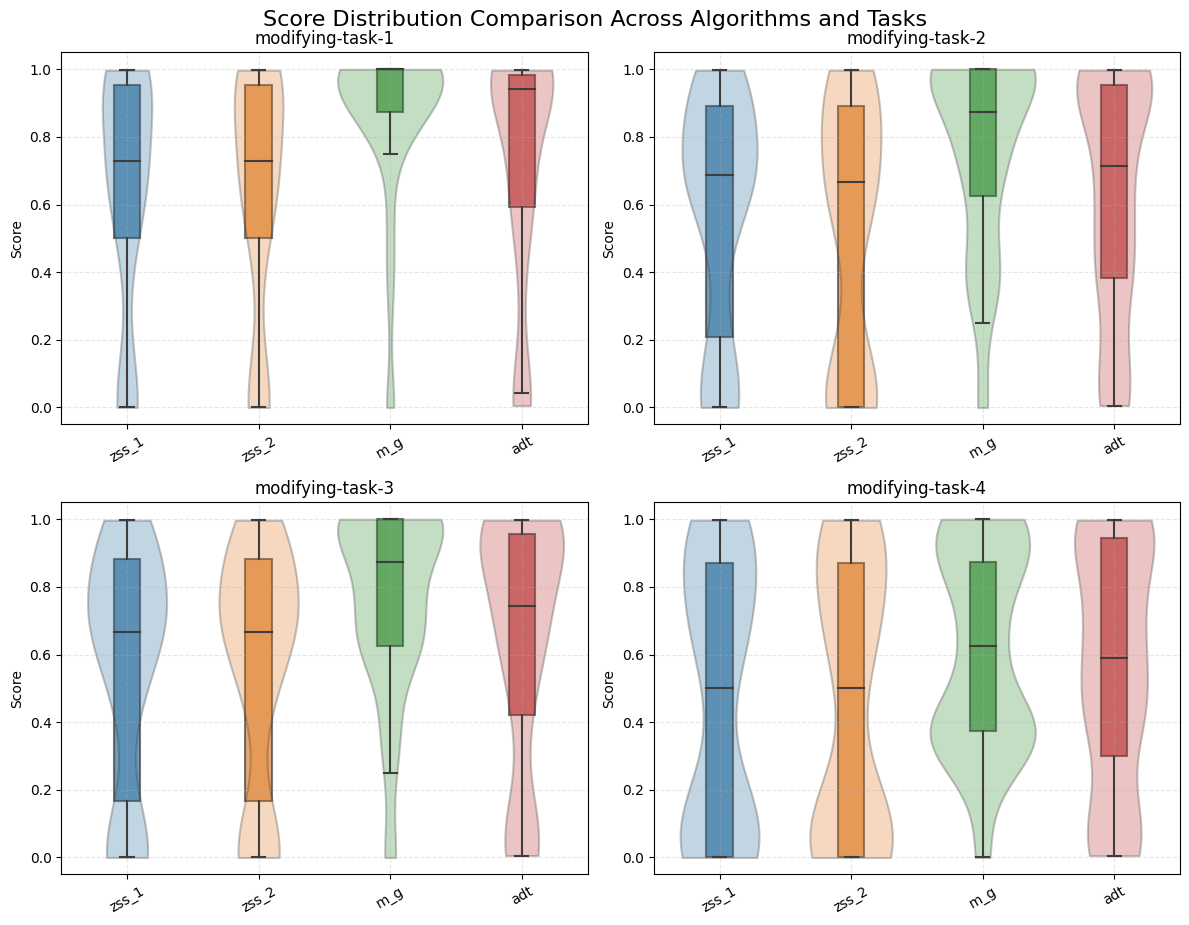

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 假设你已有这四个长表
# zss_1_long, zss_2_long, m_g_long, adt_long

# 合并成长表
df_all = pd.concat(
    [zss_1_long, zss_2_long, m_g_long, adt_long],
    ignore_index=True
)

# 准备要画的任务列表
tasks = df_all['task_id'].unique().tolist()
# 如果任务太多，只取前 4 个示例
tasks = tasks[:4]

# 算法顺序和配色
algos   = ['zss_1','zss_2','m_g','adt']
palette = sns.color_palette("tab10", n_colors=len(algos))

# 创建 2×2 子图
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=False)
axes = axes.flatten()

for ax, task in zip(axes, tasks):
    sub = df_all[df_all['task_id'] == task]
    
    # (a) 小提琴图
    sns.violinplot(
        x='algorithm', y='score',
        data=sub,
        order=algos,
        palette=palette,
        inner=None,
        cut=0,
        ax=ax
    )
    # 半透明
    from matplotlib.collections import PolyCollection
    for pc in ax.findobj(PolyCollection):
        pc.set_alpha(0.3)
    
    # (b) 箱线图
    sns.boxplot(
        x='algorithm', y='score',
        data=sub,
        order=algos,
        width=0.2,
        boxprops={'alpha':0.7},
        showcaps=True,
        showfliers=False,
        ax=ax
    )
    
    ax.set_title(task, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.set_xticklabels(algos, rotation=30)
    ax.grid(True, linestyle='--', alpha=0.3)

# 删除多余子图（如果任务少于 4 个）
for ax in axes[len(tasks):]:
    fig.delaxes(ax)

fig.suptitle('Score Distribution Comparison Across Algorithms and Tasks', fontsize=16, y=0.92)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [22]:
adt

,participantId,task_id,score,score_z,format
0,670f9ddb0e32533c222c3031,modifying-task-1,0.010309,-2.016611,json
1,671bdd06525adeea062a1d73,modifying-task-1,0.997368,0.802840,json
2,66912d7bf9d35c08f6919958,modifying-task-1,0.010309,-2.016611,json
3,6818ca1523ece90f671e3601,modifying-task-1,0.094017,-1.777506,json
4,6680d2279263349cc005956a,modifying-task-1,0.992105,0.787807,json
...,...,...,...,...,...
423,67406c1303bd39d206ff2b50,modifying-task-4,0.712810,0.429042,xml
424,67f66486e35051403284eb5e,modifying-task-4,0.711957,0.426609,xml
425,60f7c71d1cffec381351b0b3,modifying-task-4,0.709497,0.419600,xml
426,5fb4fcd1fce53c30649dd704,modifying-task-4,0.304187,-0.735594,xml


In [75]:
import pandas as pd
import numpy as np

means = (
    adt
    .groupby('participantId')[['score','score_z']]
    .mean()
    .rename(columns={'score':'mean_score','score_z':'mean_score_z'})
    .reset_index()
)

# 2) 再取每个 participant 的 format（第一个出现的那个）
formats = (
    adt
    .groupby('participantId')['format']
    .first()
    .reset_index()
)

# 3) 合并平均分和 format，构造新的行
new_rows = (
    means
    .merge(formats, on='participantId')
    .assign(
        task_id = 'modifying-task',    # 新的 task_id
        score   = lambda d: d['mean_score'],
        score_z = lambda d: d['mean_score_z']
    )
    # 最终只保留你需要的列，并保持顺序
    [['participantId','task_id','score','score_z','format']]
)

# 4) 拼回原表
df_expanded = pd.concat([adt, new_rows], ignore_index=True)

# 检查一下新增行
df_expanded


,participantId,task_id,score,score_z,format
0,66475d6f7b27e4443ef0d031,modifying-task-1,0.993490,0.392222,json
1,67e571bef6af7ecd9c29ad72,modifying-task-1,0.993490,0.392222,json
2,60f1f1d4ac991a259b83f603,modifying-task-1,0.996094,0.400819,json
3,673c13c9d37c8a73bc80b8ce,modifying-task-1,0.998698,0.409415,json
4,667ac09492ea0caadf488520,modifying-task-1,0.481771,-1.296994,json
...,...,...,...,...,...
530,67f1a4f8dd44e7cd5adffa29,modifying-task,0.253215,-1.006523,json5
531,67f1c7bd6f1c4a3d8deae02f,modifying-task,0.802181,0.394872,toml
532,67f3619e16d4ca195fbd1bd0,modifying-task,0.760178,0.295734,yaml
533,67f5bb69760b211cdfe8021c,modifying-task,0.807687,0.416782,jsonc


In [76]:
df_expanded.to_csv('m_score_tabular.csv',index=False)


In [194]:
df_expanded=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/m_score.csv')
df_expanded

,participantId,task_id,score,score_z,format
0,670f9ddb0e32533c222c3031,modifying-task-1,0.010309,-2.016611,json
1,671bdd06525adeea062a1d73,modifying-task-1,0.997368,0.802840,json
2,66912d7bf9d35c08f6919958,modifying-task-1,0.010309,-2.016611,json
3,6818ca1523ece90f671e3601,modifying-task-1,0.094017,-1.777506,json
4,6680d2279263349cc005956a,modifying-task-1,0.992105,0.787807,json
...,...,...,...,...,...
530,67f66486e35051403284eb5e,modifying-task,0.687352,0.132312,xml
531,680ebf035ab59d342f31726e,modifying-task,0.967487,0.933454,hjson
532,681374d36d7bd7ccb6f914f5,modifying-task,0.593061,-0.136519,json5
533,68138e7f96395f4c5f3a0a87,modifying-task,0.389712,-0.716688,json


In [195]:
writing_score=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/adt_writing_config_score.csv')
writing_score

,participantId,task_id,score,score_z,format
0,670f9ddb0e32533c222c3031,writing,0.172414,-0.577760,json
1,671bdd06525adeea062a1d73,writing,0.403846,0.315885,json
2,66912d7bf9d35c08f6919958,writing,0.147059,-0.675665,json
3,6818ca1523ece90f671e3601,writing,0.166667,-0.599952,json
4,6680d2279263349cc005956a,writing,0.923077,2.320825,json
...,...,...,...,...,...
102,67406c1303bd39d206ff2b50,writing,0.187500,-0.519507,xml
103,67f66486e35051403284eb5e,writing,0.038462,-1.094999,xml
104,60f7c71d1cffec381351b0b3,writing,0.288462,-0.129657,xml
105,5fb4fcd1fce53c30649dd704,writing,0.038462,-1.094999,xml


In [196]:
reading_score=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/1_reading_score_config.csv')
reading_score['score_z'] = (
    reading_score
    .groupby('task')['score']
    .transform(lambda x: (x - x.mean()) / x.std(ddof=0))
)
reading_score

,participantId,task,format,correct count,score,score_z
0,67895b7d6400163124042af7,reading-task-config-1,jsonc,1,1.0,0.419314
1,67895b7d6400163124042af7,reading-task-config-2,jsonc,0,0.0,-1.911066
2,67895b7d6400163124042af7,reading-task-config-3,jsonc,1,1.0,0.321081
3,67895b7d6400163124042af7,reading-task-config-4,jsonc,0,0.0,-1.108678
4,67895b7d6400163124042af7,reading-task-config-5,jsonc,0,0.0,-2.223611
...,...,...,...,...,...,...
637,67f66486e35051403284eb5e,reading-task-config,xml,3,0.6,-0.822491
638,680ebf035ab59d342f31726e,reading-task-config,hjson,5,1.0,0.955418
639,681374d36d7bd7ccb6f914f5,reading-task-config,json5,4,0.8,0.066464
640,68138e7f96395f4c5f3a0a87,reading-task-config,json,4,0.8,0.066464


In [197]:
reading_score=reading_score[['participantId','task','score','score_z','format']]
reading_score['task'] = reading_score['task'].replace({
    'reading-task-config-1': 'reading-task-1',
    'reading-task-config-2': 'reading-task-2',
    'reading-task-config-3': 'reading-task-3',
    'reading-task-config-4': 'reading-task-4',
    'reading-task-config-5': 'reading-task-5',
    'reading-task-config': 'reading-task',
})
reading_score.rename(columns={'task': 'task_id'}, inplace=True)
reading_score

/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_75184/1781507772.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reading_score['task'] = reading_score['task'].replace({
/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_75184/1781507772.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reading_score.rename(columns={'task': 'task_id'}, inplace=True)


,participantId,task_id,score,score_z,format
0,67895b7d6400163124042af7,reading-task-1,1.0,0.419314,jsonc
1,67895b7d6400163124042af7,reading-task-2,0.0,-1.911066,jsonc
2,67895b7d6400163124042af7,reading-task-3,1.0,0.321081,jsonc
3,67895b7d6400163124042af7,reading-task-4,0.0,-1.108678,jsonc
4,67895b7d6400163124042af7,reading-task-5,0.0,-2.223611,jsonc
...,...,...,...,...,...
637,67f66486e35051403284eb5e,reading-task,0.6,-0.822491,xml
638,680ebf035ab59d342f31726e,reading-task,1.0,0.955418,hjson
639,681374d36d7bd7ccb6f914f5,reading-task,0.8,0.066464,json5
640,68138e7f96395f4c5f3a0a87,reading-task,0.8,0.066464,json


In [198]:
total_score=pd.concat([reading_score,writing_score,df_expanded])
total_score

,participantId,task_id,score,score_z,format
0,67895b7d6400163124042af7,reading-task-1,1.000000,0.419314,jsonc
1,67895b7d6400163124042af7,reading-task-2,0.000000,-1.911066,jsonc
2,67895b7d6400163124042af7,reading-task-3,1.000000,0.321081,jsonc
3,67895b7d6400163124042af7,reading-task-4,0.000000,-1.108678,jsonc
4,67895b7d6400163124042af7,reading-task-5,0.000000,-2.223611,jsonc
...,...,...,...,...,...
530,67f66486e35051403284eb5e,modifying-task,0.687352,0.132312,xml
531,680ebf035ab59d342f31726e,modifying-task,0.967487,0.933454,hjson
532,681374d36d7bd7ccb6f914f5,modifying-task,0.593061,-0.136519,json5
533,68138e7f96395f4c5f3a0a87,modifying-task,0.389712,-0.716688,json


In [199]:
total_score.rename(columns={'task_id': 'task'}, inplace=True)

In [200]:
total_score.to_csv('/Users/shiyihe/Desktop/VIS_RESULT/total_score_config.csv',index=False)

In [84]:
new_score = total_score[
    total_score['task_id'].isin([
        'modifying-task',
        'reading-task',
        'writing'
    ])
]
sum_z = (
    new_score
    .groupby('participantId')['score_z']
    .sum()
    .reset_index(name='sum_score_z')
)

# 2) 如果你还想保留每个人的算法 format （假设 format 在所有行里都是一样的），
#    可以顺便取一个“第一行”的 format
formats = (
    new_score
    .groupby('participantId')['format']
    .first()
    .reset_index()
)

# 3) 合并
result = sum_z.merge(formats, on='participantId')

# 看一下
result['task']='user_study'
result


,participantId,sum_score_z,format,task
0,56cb8858edf8da000b6df354,0.787108,hjson,user_study
1,57c357770e6a1f00015f6038,-0.008300,json,user_study
2,5b68c9eb87af310001584803,-1.165757,json5,user_study
3,5c6414540821d30001046198,0.519737,hjson,user_study
4,5d30dfa68b1523000134878f,1.282446,json,user_study
...,...,...,...,...
102,67f1a4f8dd44e7cd5adffa29,-1.598565,json5,user_study
103,67f1c7bd6f1c4a3d8deae02f,0.661481,toml,user_study
104,67f3619e16d4ca195fbd1bd0,-0.287935,yaml,user_study
105,67f5bb69760b211cdfe8021c,0.712357,jsonc,user_study


In [85]:
result.to_csv('/Users/shiyihe/Desktop/VIS_RESULT/result_tabular.csv',index=False)

In [3]:
import pandas as pd
result_tabular=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/result_tabular.csv')
result_config=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/result_config.csv')
result=pd.concat([result_tabular,result_config])
result

,participantId,sum_score_z,format,task
0,56cb8858edf8da000b6df354,0.787108,hjson,user_study
1,57c357770e6a1f00015f6038,-0.008300,json,user_study
2,5b68c9eb87af310001584803,-1.165757,json5,user_study
3,5c6414540821d30001046198,0.519737,hjson,user_study
4,5d30dfa68b1523000134878f,1.282446,json,user_study
...,...,...,...,...
102,67f66486e35051403284eb5e,-1.785178,xml,user_study
103,680ebf035ab59d342f31726e,1.610701,hjson,user_study
104,681374d36d7bd7ccb6f914f5,2.473541,json5,user_study
105,68138e7f96395f4c5f3a0a87,-1.342113,json,user_study


In [4]:
import pandas as pd
from scipy.stats import shapiro, levene, f_oneway, kruskal, mannwhitneyu
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations

def compare_format_effect(
    df: pd.DataFrame,
    value_col: str = 'duration_sec',
    method: str = 'anova',
    alpha: float = 0.05
):
    """
    比较每个 task 上 format 对指定数值列的影响。

    参数
    ----
    df : pandas.DataFrame
        必须包含 ['participantId','task', value_col,'format']。
    value_col : str
        要比较的数值列名，原来固定为 'duration_sec'。
    method : {'anova','kruskal'}
        anova 模式下做 Shapiro+Levene 前置检验，否则 Kruskal–Wallis。
    alpha : float
        显著性水平。

    返回
    ----
    summary_df, posthoc_df, reg_tables
    """
    tasks = df['task'].unique()
    summary = []
    posthoc_list = []
    reg_tables = {}

    for task in tasks:
        print(tasks)
        print(task)
        sub = df[df['task'] == task]
        formats = sub['format'].unique()
        # 构造各组数据
        groups = [g[value_col].values for _, g in sub.groupby('format')]
        if len(groups) < 2:
            continue  # 至少两个组才比较

        test_name = method.upper()
        try:
            # ANOVA 分支
            if method == 'anova':
                # 正态性检验
                for fmt, series in sub.groupby('format')[value_col]:
                    if len(series) < 3:
                        raise ValueError(f"Task={task}, format={fmt} 样本量 {len(series)} < 3，无法做 Shapiro")
                    _, p_s = shapiro(series)
                    if p_s < alpha:
                        raise ValueError(f"Task={task}, format={fmt} Shapiro p={p_s:.3f} < {alpha}")
                # 方差齐性
                _, p_l = levene(*groups)
                if p_l < alpha:
                    raise ValueError(f"Task={task} Levene p={p_l:.3f} < {alpha}")
                # 一元 ANOVA
                stat, p = f_oneway(*groups)
            # Kruskal 分支
            elif method == 'kruskal':
                stat, p = kruskal(*groups)
            else:
                raise ValueError("method 必须为 'anova' 或 'kruskal'")

            # 保存汇总
            signif = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
            summary.append({
                'task': task,
                'stat': stat,
                'p_value': p,
                'test': test_name,
                'signif': signif
            })

            # 显著则做事后和回归
            if p < alpha:
                # 事后比较
                if method == 'anova':
                    tukey = pairwise_tukeyhsd(
                        endog=sub[value_col],
                        groups=sub['format'],
                        alpha=alpha
                    )
                    df_tukey = pd.DataFrame(
                        tukey.summary().data[1:],
                        columns=tukey.summary().data[0]
                    )
                    sig = df_tukey[df_tukey['reject']]
                    sig['task'] = task
                    posthoc_list.append(sig[['task','group1','group2','p-adj','reject']])
                else:
                    m = len(formats)
                    n_pairs = m*(m-1)/2
                    pairs = []
                    for f1, f2 in combinations(formats, 2):
                        d1 = sub[sub['format']==f1][value_col]
                        d2 = sub[sub['format']==f2][value_col]
                        _, p_u = mannwhitneyu(d1, d2, alternative='two-sided')
                        p_adj = min(p_u * n_pairs, 1.0)
                        if p_adj < alpha:
                            pairs.append({
                                'task': task,
                                'group1': f1,
                                'group2': f2,
                                'p_unc': p_u,
                                'p_adj': p_adj,
                                'signif': '*'
                            })
                    if pairs:
                        posthoc_list.append(pd.DataFrame(pairs))

                # 回归
                formula = f"{value_col} ~ C(format)"
                model = ols(formula, data=sub).fit()
                tbl = model.summary2().tables[1].copy()
                tbl['signif'] = tbl['P>|t|'].apply(
                    lambda x: '***' if x<0.001 else '**' if x<0.01 else '*' if x<0.05 else ''
                )
                reg_tables[task] = tbl

        except ValueError:
            # 不满足前置假设，直接跳出到下一个 task
            continue

    summary_df = pd.DataFrame(summary)
    posthoc_df = pd.concat(posthoc_list, ignore_index=True) if posthoc_list else pd.DataFrame()
    return summary_df, posthoc_df, reg_tables


result
summary_df, posthoc_df, reg_tables= compare_format_effect(result, value_col='sum_score_z', method='kruskal')

# 比较别的数值列 e.g. 'time_ms'
# s2s1, p2, r2 = compare_format_effect(df, value_col='time_ms', method='kruskal')
summary_df

['user_study']
user_study


,task,stat,p_value,test,signif
0,user_study,28.31591,0.000082,KRUSKAL,***


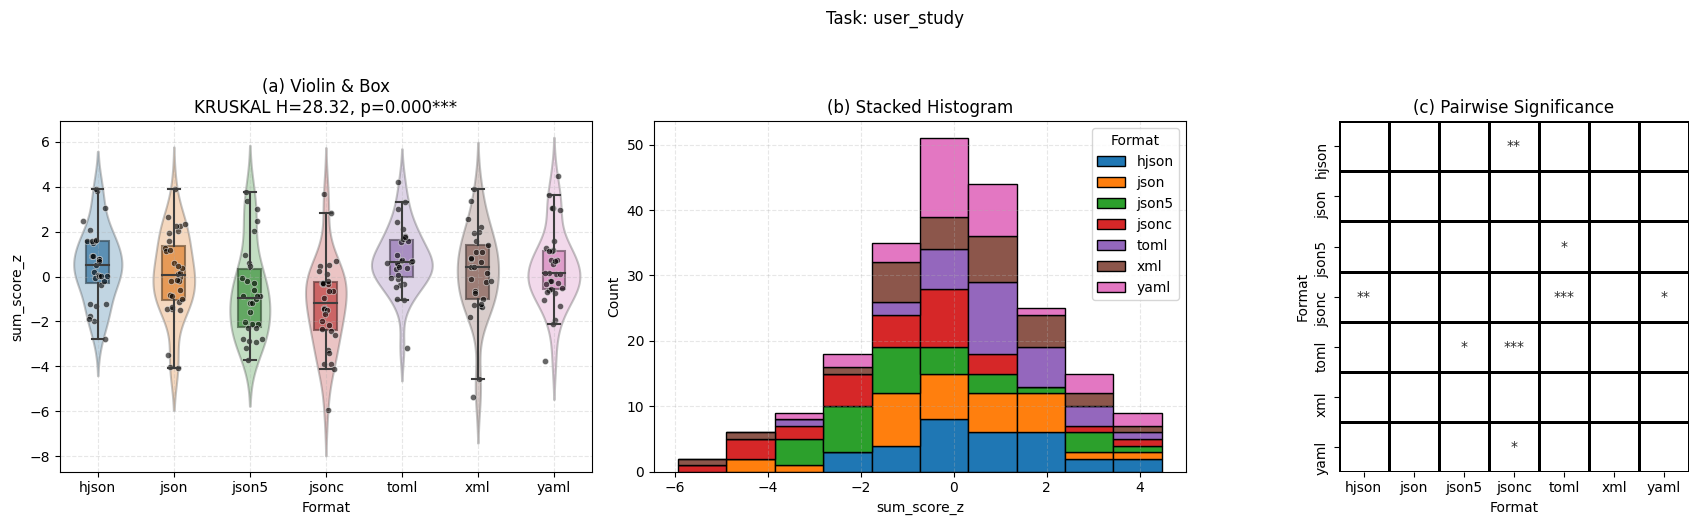

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_format_differences_continuous(
    df: pd.DataFrame,
    compare_res: dict,
    task_list: list,
    participant_col: str = 'participantId',
    value_col: str = 'duration_sec',   # <— 可替换为任意连续列
    group_col: str = 'format',
    subtask_col: str = 'task',
    alpha: float = 0.05,
    palette: list = None
) -> dict:
    """
    可视化每个任务下不同 format 对连续变量 value_col 的影响：
     (a) 半透明 Violin+Box+散点 + 全局检验标签
     (b) 堆叠直方图
     (c) 格式×格式 事后检验星号热图

    compare_res = {
      'global_df': DataFrame with ['task','stat','p_value','test','signif'],
      'posthoc':   DataFrame or dict of DataFrames
    }
    """
    formats = sorted(df[group_col].unique().tolist())
    if palette is None:
        palette = sns.color_palette("tab10", n_colors=len(formats))
    global_df    = compare_res['global_df']
    posthoc_all  = compare_res.get('posthoc', pd.DataFrame())
    figs = {}

    for task in task_list:
        # 1) 准备数据
        if task == 'total':
            data = (
                df
                .groupby([participant_col, group_col])[value_col]
                .sum()
                .reset_index()
            )
            ylabel = f"Total {value_col}"
        else:
            data = df[df[subtask_col] == task]
            ylabel = value_col

        # 2) 全局检验标签
        row = global_df[global_df['task'] == task]
        if not row.empty:
            row      = row.iloc[0]
            stat_chr = 'H' if row['test'].lower().startswith('kruskal') else 'F'
            stat_val = row['stat']
            pval     = row['p_value']
            stars    = row.get('signif','') or (
                '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else ''
            )
            test_label = f"{row['test']} {stat_chr}={stat_val:.2f}, p={pval:.3f}{stars}"
        else:
            test_label = "No global test"

        # 3) 本 task 的 posthoc
        if isinstance(posthoc_all, dict):
            post_df = posthoc_all.get(task, pd.DataFrame())
        else:
            post_df = posthoc_all[
                posthoc_all.get('task',pd.Series()) == task
            ] if 'task' in posthoc_all.columns else pd.DataFrame()

        # 4) 构建星号矩阵
        star_mat = pd.DataFrame('', index=formats, columns=formats)
        if not post_df.empty:
            pcol = 'p-adj' if 'p-adj' in post_df.columns else 'p_adj'
            for _, r in post_df.iterrows():
                s = '***' if r[pcol]<0.001 else '**' if r[pcol]<0.01 else '*' if r[pcol]<0.05 else ''
                star_mat.loc[r['group1'], r['group2']] = s
                star_mat.loc[r['group2'], r['group1']] = s

        # 5) 开始绘图
        fig, axes = plt.subplots(1,3,figsize=(18,5))
        fig.suptitle(f"Task: {task}", y=1.04)

        # (a) Violin + Box + Scatter
        ax1 = axes[0]
        viols = sns.violinplot(
            data    = data,
            x       = group_col,
            y       = value_col,
            order   = formats,
            palette = palette,
            inner   = None,
            ax      = ax1
        )
        # 手动降低小提琴的 alpha
        from matplotlib.collections import PolyCollection
        for pc in ax1.findobj(PolyCollection):
            pc.set_alpha(0.3)

        sns.boxplot(
            data       = data,
            x          = group_col,
            y          = value_col,
            order      = formats,
            palette    = palette,
            width      = 0.3,
            boxprops   = {'alpha':0.7},
            showfliers = False,
            ax         = ax1
        )
        # 散点
        for i,fmt in enumerate(formats):
            yv = data.loc[data[group_col]==fmt, value_col]
            xs = np.random.normal(i,0.08,size=len(yv))
            ax1.scatter(xs,yv, color='black', s=20, alpha=0.6,
                        edgecolors='white', linewidth=0.5)
        ax1.set_title(f"(a) Violin & Box\n{test_label}")
        ax1.set_xlabel("Format"); ax1.set_ylabel(ylabel)
        ax1.grid(True,linestyle='--',alpha=0.3)

        # (b) Stacked Histogram
        ax2 = axes[1]
        vals = [data.loc[data[group_col]==fmt, value_col] for fmt in formats]
        ax2.hist(vals, bins=10, stacked=True,
                 label=formats, color=palette, edgecolor='black')
        ax2.set_title("(b) Stacked Histogram")
        ax2.set_xlabel(ylabel); ax2.set_ylabel("Count")
        ax2.legend(title="Format"); ax2.grid(True,linestyle='--',alpha=0.3)

        # (c) Pairwise Significance Heatmap
        ax3 = axes[2]
        sns.heatmap(
            np.zeros((len(formats),len(formats))),
            annot     = star_mat.values,
            fmt       = '',
            cmap      = 'Greys',
            cbar      = False,
            linewidths=1,
            linecolor ='black',
            xticklabels=formats,
            yticklabels=formats,
            square    = True,
            ax        = ax3
        )
        ax3.set_title("(c) Pairwise Significance")
        ax3.set_xlabel("Format"); ax3.set_ylabel("Format")

        plt.tight_layout()
        figs[task] = fig

    return figs

compare_res = {
    'global_df': summary_df,
    'posthoc': posthoc_df  # 或者你自己整理好的 { task_name: df_task }
}

# 明确传入你要画的任务列表
tasks_to_draw = ['user_study']
# base = sns.color_palette("tab10", 7)
# palette = [(r, g, b, 0.3) for r, g, b in base]

figures = plot_format_differences_continuous(
    result,
    compare_res,
    task_list=tasks_to_draw,
    participant_col='participantId',
    value_col='sum_score_z',
    group_col='format',
    subtask_col='task',
    alpha=0.05
)

# 显示或保存
# figures['modifying-task-tabular-2'].show()


In [67]:
total_score.rename(columns={'task_id': 'task'}, inplace=True)
total_score

,participantId,task,score,score_z,format
0,67895b7d6400163124042af7,reading-task-1,1.000000,0.419314,jsonc
1,67895b7d6400163124042af7,reading-task-2,0.000000,-1.911066,jsonc
2,67895b7d6400163124042af7,reading-task-3,1.000000,0.321081,jsonc
3,67895b7d6400163124042af7,reading-task-4,0.000000,-1.108678,jsonc
4,67895b7d6400163124042af7,reading-task-5,0.000000,-2.223611,jsonc
...,...,...,...,...,...
530,67f66486e35051403284eb5e,modifying-task,0.687352,0.132312,xml
531,680ebf035ab59d342f31726e,modifying-task,0.967487,0.933454,hjson
532,681374d36d7bd7ccb6f914f5,modifying-task,0.593061,-0.136519,json5
533,68138e7f96395f4c5f3a0a87,modifying-task,0.389712,-0.716688,json


In [102]:
quiz_c=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/2_quiz_result_config.csv')
quiz_t=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/2_quiz_result_tabular.csv')
quiz=pd.concat([quiz_c,quiz_t])
quiz

,participantId,task,num_wrong_attempts,correct,format
0,5755c957eb80c4000741a9ce,tutorial_quiz,3,1.0,json5
1,5795af044a84da00014c5df1,tutorial_quiz,1,1.0,json
2,57ca4b09993b08000192297b,tutorial_quiz,2,1.0,xml
3,588ab33542c8e900019d02ae,tutorial_quiz,2,1.0,jsonc
4,589cd166b2a7180001f0527d,tutorial_quiz,7,0.5,jsonc
...,...,...,...,...,...
102,67f1a4f8dd44e7cd5adffa29,tutorial_quiz,3,1.0,json5
103,67f1c7bd6f1c4a3d8deae02f,tutorial_quiz,0,1.0,toml
104,67f3619e16d4ca195fbd1bd0,tutorial_quiz,3,1.0,yaml
105,67f5bb69760b211cdfe8021c,tutorial_quiz,5,0.5,jsonc


In [ ]:
quzi

In [119]:
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
from itertools import combinations

def compare_format_effect_categorical(
    df: pd.DataFrame,
    outcome_col: str,
    positive_label=None,
    method: str = 'chi2',
    alpha: float = 0.05
):
    """
    比较每个 task 上 format 对 二分类/多分类 outcome_col 的影响。

    参数
    ----
    df : pandas.DataFrame
        必须包含 ['participantId','task', outcome_col,'format']。
    outcome_col : str
        要检验的分类列名（比如 'correct'）。
    positive_label : optional
        如果是二分类，指定哪一个值视为“成功”（1），否则留 None。
    method : {'chi2','fisher'}
        chi2 模式下做整体卡方检验；fisher 下批量做 2x2 Fisher 精确检验（仅限二分类）。
    alpha : float
        显著性水平。

    返回
    ----
    summary_df : DataFrame
        每个 task 的全局检验结果，列 ['task','stat','p_value','test','signif']。
    posthoc_df : DataFrame
        显著 task 的两两事后比较，仅保留 p_adj<alpha：
          ['task','group1','group2','p_unc','p_adj','signif']。
    """
    tasks = df['task'].unique()
    summary = []
    posthoc = []

    for task in tasks:
        sub = df[df['task'] == task]
        formats = sub['format'].unique()
        if len(formats) < 2:
            continue

        # 构建 格式 × outcome 的列联表
        ct = pd.crosstab(sub['format'], sub[outcome_col])
        # 如果是二分类，确保 positive_label 在列索引中
        if positive_label is not None and positive_label not in ct.columns:
            raise ValueError(f"{outcome_col} 不包含值 {positive_label}")
        
        # 全局检验
        if method == 'chi2':
            stat, p, _, _ = chi2_contingency(ct)
            test_name = 'Chi2'
        elif method == 'fisher':
            # Fisher 只能对 2×2 做一次检验——若多组、多分类不适用
            if ct.shape != (2,2):
                raise ValueError("Fisher 精确检验仅适用于 2×2 列联表")
            (a,b),(c,d) = ct.values
            stat, p = fisher_exact([[a,b],[c,d]])
            test_name = 'Fisher'
        else:
            raise ValueError("method 必须为 'chi2' 或 'fisher'")

        signif = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        summary.append({
            'task': task,
            'stat': stat,
            'p_value': p,
            'test': test_name,
            'signif': signif
        })

        # 只有显著时做事后两两比较
        if p < alpha:
            m = len(formats)
            n_pairs = m*(m-1)/2
            for f1, f2 in combinations(formats, 2):
                sub12 = sub[sub['format'].isin([f1, f2])]
                ct12 = pd.crosstab(sub12['format'], sub12[outcome_col])
                # 若二分类且 Fisher 模式
                if method=='fisher' and ct12.shape==(2,2):
                    (a,b),(c,d) = ct12.values
                    _, p_u = fisher_exact([[a,b],[c,d]])
                    p_adj = min(p_u * n_pairs, 1.0)
                else:
                    # 对任意大小列联表都用卡方
                    stat2, p_u, _, _ = chi2_contingency(ct12)
                    p_adj = min(p_u * n_pairs, 1.0)
                if p_adj < alpha:
                    signif2 = '*' if p_adj<0.05 else ''
                    posthoc.append({
                        'task':   task,
                        'group1': f1,
                        'group2': f2,
                        'p_unc':  p_u,
                        'p_adj':  p_adj,
                        'signif': signif2
                    })

    summary_df = pd.DataFrame(summary)
    posthoc_df = pd.DataFrame(posthoc)
    return summary_df, posthoc_df

# 假设你的 df 长这样：
#    participantId        task        correct   format
# 0  56cb8858...   tutorial_quiz      1.0      hjson
# 1  57c35777...   tutorial_quiz      1.0      json
# …

# 做卡方检验（多分类列联表）
sum_df, post_df = compare_format_effect_categorical(
    quiz,
    outcome_col='num_wrong_attempts',
    method='chi2',
    alpha=0.05
)
sum_df

,task,stat,p_value,test,signif
0,tutorial_quiz,73.891315,0.236147,Chi2,


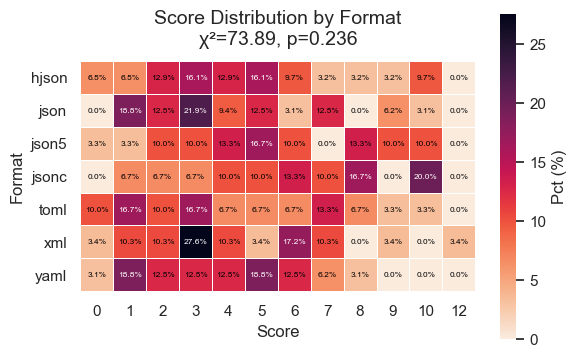

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np

# 假设 df 包含 ['format','score']
prop = pd.crosstab(quiz['format'], quiz['num_wrong_attempts'], normalize='index') * 100
chi2, p, _, _ = chi2_contingency(pd.crosstab(quiz['format'], quiz['num_wrong_attempts']))

# 颜色和样式设定
sns.set_theme(context='notebook', style='white')
cmap = sns.color_palette("rocket_r", as_cmap=True)

plt.figure(figsize=(6,5))
ax = sns.heatmap(
    prop,
    cmap=cmap,
    cbar_kws={'label': 'Pct (%)', 'shrink': 0.7},
    linewidths=0.5,
    linecolor='white',
    square=True,
    xticklabels=True,
    yticklabels=True,
    annot=False  # 先不画注释，后面手动
)

# 手动在每个单元格里写注释，并根据背景深浅自动调整文字颜色
for (i, j), v in np.ndenumerate(prop.values):
    color = 'white' if v > prop.values.max()/2 else 'black'
    ax.text(
        j + 0.5, i + 0.5,       # 单元格中心
        f"{v:.1f}%",             # 1 位小数
        ha='center', va='center',
        color=color,
        fontsize=6
    )

# 标题和坐标
ax.set_title(
    f"Score Distribution by Format\n"
    f"χ²={chi2:.2f}, p={p:.3f}",
    fontsize=14, pad=12
)
ax.set_xlabel("Score", fontsize=12)
ax.set_ylabel("Format", fontsize=12)

# 美化刻度
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

# 去掉上右边框
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


In [129]:
df_quiz_config=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/2_quiz_config.csv')
df_quiz_config=df_quiz_config[['participantId','quiz_key','correct','num_wrong_attempts','format']]
df_quiz_config.rename(columns={'quiz_key':'task'},inplace=True)
df_quiz_config['task'] = df_quiz_config['task'].replace({
    'tutorial-jsonc-part1': 'tutorial-part1',
    'tutorial-jsonc-part2': 'tutorial-part2',
    'tutorial-json-part1': 'tutorial-part1',
    'tutorial-json-part2': 'tutorial-part2',
    'tutorial-json5-part1': 'tutorial-part1',
    'tutorial-json5-part2': 'tutorial-part2',
    'tutorial-hjson-part1': 'tutorial-part1',
    'tutorial-hjson-part2': 'tutorial-part2',
    'tutorial-yaml-part1': 'tutorial-part1',
    'tutorial-yaml-part2': 'tutorial-part2',
    'tutorial-toml-part1': 'tutorial-part1',
    'tutorial-toml-part2': 'tutorial-part2',
    'tutorial-xml-part1': 'tutorial-part1',
    'tutorial-xml-part2': 'tutorial-part2',
})
df_quiz_tabular=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/2_quiz_tabular.csv')
df_quiz_tabular=df_quiz_tabular[['participantId','quiz_key','correct','num_wrong_attempts','format']]
df_quiz_tabular.rename(columns={'quiz_key':'task'},inplace=True)
df_quiz_tabular['task'] = df_quiz_tabular['task'].replace({
    'tutorial-jsonc-part1': 'tutorial-part1',
    'tutorial-jsonc-part2': 'tutorial-part2',
    'tutorial-json-part1': 'tutorial-part1',
    'tutorial-json-part2': 'tutorial-part2',
    'tutorial-json5-part1': 'tutorial-part1',
    'tutorial-json5-part2': 'tutorial-part2',
    'tutorial-hjson-part1': 'tutorial-part1',
    'tutorial-hjson-part2': 'tutorial-part2',
    'tutorial-yaml-part1': 'tutorial-part1',
    'tutorial-yaml-part2': 'tutorial-part2',
    'tutorial-toml-part1': 'tutorial-part1',
    'tutorial-toml-part2': 'tutorial-part2',
    'tutorial-xml-part1': 'tutorial-part1',
    'tutorial-xml-part2': 'tutorial-part2',
})
df_quiz=pd.concat([df_quiz_config,df_quiz_tabular])
df_quiz

,participantId,task,correct,num_wrong_attempts,format
0,67895b7d6400163124042af7,tutorial-part1,1,5,jsonc
1,67895b7d6400163124042af7,tutorial-part2,0,5,jsonc
2,659960f32faa4ff4b116de92,tutorial-part1,1,4,toml
3,659960f32faa4ff4b116de92,tutorial-part2,1,1,toml
4,5f7f239e9b204e05b6c36538,tutorial-part1,0,5,json5
...,...,...,...,...,...
209,67f1c7bd6f1c4a3d8deae02f,tutorial-part2,1,0,toml
210,67adb27bd5f5776fcb16da62,tutorial-part1,1,3,hjson
211,67adb27bd5f5776fcb16da62,tutorial-part2,1,1,hjson
212,6675c40cdc52b37294f0514e,tutorial-part1,0,5,hjson


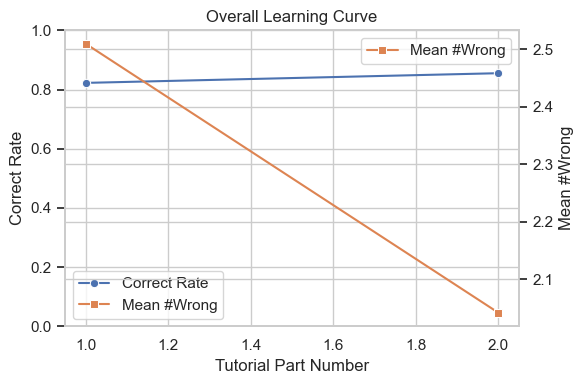

In [152]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 假设你的 DataFrame 叫 df，示例列有：
# ['participantId','task','correct','num_wrong_attempts','format']

# 1) 仅保留 tutorial 部分
tut = df_quiz[df_quiz['task'].str.startswith('tutorial-part')].copy()

# 2) 从 task 名里提取 part 序号，比如 tutorial-part1 → 1
tut['part_no'] = tut['task'].str.extract(r'tutorial\-part(\d+)').astype(int)

# 3) 计算每个 part 的平均正确率和平均错误次数
learning = (
    tut
    .groupby('part_no')
    .agg(
        correct_rate = ('correct', 'mean'),           # 正确率
        mean_wrong   = ('num_wrong_attempts', 'mean')  # 平均错误次数
    )
    .reset_index()
)

# learning 看起来像：
#    part_no  correct_rate  mean_wrong
# 0        1      0.75          3.4
# 1        2      0.82          2.1

# 4) 绘制整体学习曲线
sns.set_theme(style='whitegrid')
plt.figure(figsize=(6,4))
ax1 = plt.gca()

# 正确率曲线
sns.lineplot(
    data=learning,
    x='part_no', y='correct_rate',
    marker='o', label='Correct Rate', ax=ax1
)
ax1.set_ylabel('Correct Rate')
ax1.set_ylim(0,1)

# 平均错误次数用第二条 y 轴
ax2 = ax1.twinx()
sns.lineplot(
    data=learning,
    x='part_no', y='mean_wrong',
    marker='s', color='C1', label='Mean #Wrong', ax=ax2
)
ax2.set_ylabel('Mean #Wrong')

# 标题 & 轴
ax1.set_xlabel('Tutorial Part Number')
plt.title('Overall Learning Curve')
# 合并两条 legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, loc='best')

plt.tight_layout()
plt.show()


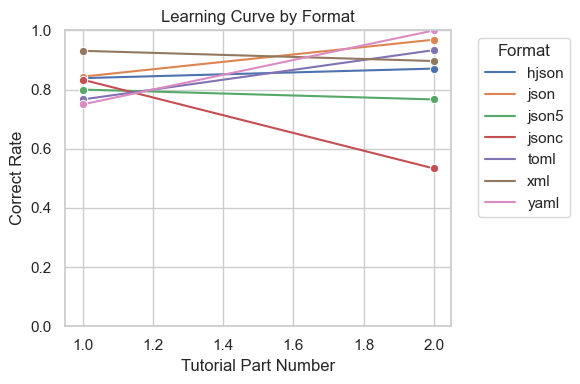

In [153]:
# 5) 分 format 计算
learning_fmt = (
    tut
    .groupby(['format','part_no'])
    .agg(
        correct_rate=('correct','mean'),
        mean_wrong=('num_wrong_attempts','mean')
    )
    .reset_index()
)

# 6) 分 format 画多条正确率曲线
plt.figure(figsize=(6,4))
sns.lineplot(
    data=learning_fmt,
    x='part_no', y='correct_rate',
    hue='format', marker='o'
)
plt.ylim(0,1)
plt.xlabel('Tutorial Part Number')
plt.ylabel('Correct Rate')
plt.title('Learning Curve by Format')
plt.legend(bbox_to_anchor=(1.05,1), title='Format')
plt.tight_layout()
plt.show()


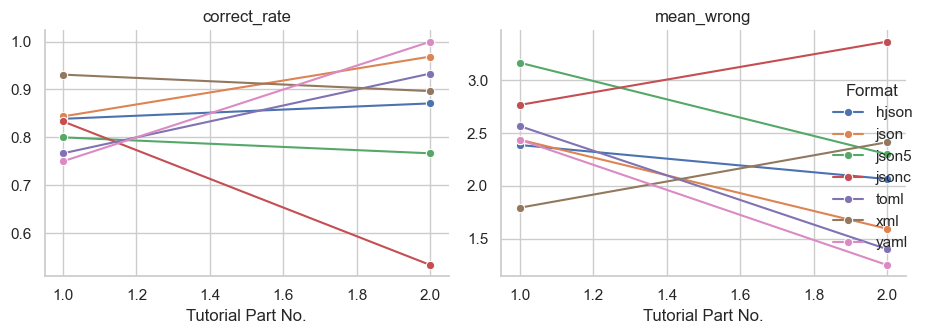

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

# 正确的“融化”写法
# 正确的“融化”写法
melted = learning_fmt.melt(
    id_vars=['format','part_no'],
    value_vars=['correct_rate','mean_wrong'],
    var_name='metric',
    value_name='value'
)

# 分面绘图，使用 map_dataframe
g = sns.FacetGrid(
    melted,
    col='metric',
    hue='format',      # 只在这里指定一次
    sharey=False,
    height=3.5,
    aspect=1.2
)

# 2) map_dataframe 画线，不再重复传 hue
g.map_dataframe(
    sns.lineplot,
    x='part_no',
    y='value',
    marker='o'
)

# 3) 只这一处添加图例
g.add_legend(title='Format')

# 4) 标签和标题
g.set_axis_labels('Tutorial Part No.', '')
g.set_titles('{col_name}')

plt.tight_layout()
plt.show()

In [150]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# 假设我们已经有 tut DataFrame，含这几列：
# ['participantId','task','correct','num_wrong_attempts','format']
# 并且已经提取了 part_no 和 attempts 列，如前面所示：

tut = df_quiz[df_quiz['task'].str.startswith('tutorial-part')].copy()
tut['part_no'] = tut['task'].str.extract(r'part(\d+)').astype(int)
tut['attempts'] = tut['num_wrong_attempts'] + tut['correct']

# 1) 按 format & part_no 聚合，算出每步的平均正确率和平均错误
agg = (
    tut
    .groupby(['format','part_no'])
    .agg(
      correct_rate=('correct','mean'),
      mean_wrong   =('num_wrong_attempts','mean'),
      mean_attempts=('attempts','mean')
    )
    .reset_index()
)

# 2) 对每个 format，计算 part_no 与 correct_rate 的 Pearson r 和 p
results = []
for fmt, sub in agg.groupby('format'):
    # sub['part_no']、sub['correct_rate'] 一般长度就是 tutorial-part 的步数
    r_corr, p_corr = pearsonr(sub['part_no'], sub['correct_rate'])
    r_wrong, p_wrong = pearsonr(sub['part_no'], sub['mean_wrong'])
    r_att,   p_att   = pearsonr(sub['part_no'], sub['mean_attempts'])
    results.append({
        'format': fmt,
        'r_correct_rate': r_corr,
        'p_correct_rate': p_corr,
        'r_mean_wrong': r_wrong,
        'p_mean_wrong': p_wrong,
        'r_mean_attempts': r_att,
        'p_mean_attempts': p_att
    })

corr_df = pd.DataFrame(results).sort_values('format').reset_index(drop=True)
corr_df


,format,r_correct_rate,p_correct_rate,r_mean_wrong,p_mean_wrong,r_mean_attempts,p_mean_attempts
0,hjson,1.0,1.0,-1.0,1.0,-1.0,1.0
1,json,1.0,1.0,-1.0,1.0,-1.0,1.0
2,json5,-1.0,1.0,-1.0,1.0,-1.0,1.0
3,jsonc,-1.0,1.0,1.0,1.0,1.0,1.0
4,toml,1.0,1.0,-1.0,1.0,-1.0,1.0
5,xml,-1.0,1.0,1.0,1.0,1.0,1.0
6,yaml,1.0,1.0,-1.0,1.0,-1.0,1.0


In [157]:
total_score

,participantId,task,score,score_z,format
0,64457bc906c125cebd4bf66b,reading-task-1,0.000000,-2.384848,json5
1,64457bc906c125cebd4bf66b,reading-task-2,1.000000,0.264575,json5
2,64457bc906c125cebd4bf66b,reading-task-3,1.000000,0.667792,json5
3,64457bc906c125cebd4bf66b,reading-task-4,1.000000,0.303046,json5
4,64457bc906c125cebd4bf66b,reading-task-5,1.000000,0.803837,json5
...,...,...,...,...,...
530,67f1a4f8dd44e7cd5adffa29,modifying-task,0.253215,-1.006523,json5
531,67f1c7bd6f1c4a3d8deae02f,modifying-task,0.802181,0.394872,toml
532,67f3619e16d4ca195fbd1bd0,modifying-task,0.760178,0.295734,yaml
533,67f5bb69760b211cdfe8021c,modifying-task,0.807687,0.416782,jsonc


In [228]:
total_score=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/total_score_config.csv')
total_score

,participantId,task,score,score_z,format
0,67895b7d6400163124042af7,reading-task-1,1.000000,0.419314,jsonc
1,67895b7d6400163124042af7,reading-task-2,0.000000,-1.911066,jsonc
2,67895b7d6400163124042af7,reading-task-3,1.000000,0.321081,jsonc
3,67895b7d6400163124042af7,reading-task-4,0.000000,-1.108678,jsonc
4,67895b7d6400163124042af7,reading-task-5,0.000000,-2.223611,jsonc
...,...,...,...,...,...
1279,67f66486e35051403284eb5e,modifying-task,0.687352,0.132312,xml
1280,680ebf035ab59d342f31726e,modifying-task,0.967487,0.933454,hjson
1281,681374d36d7bd7ccb6f914f5,modifying-task,0.593061,-0.136519,json5
1282,68138e7f96395f4c5f3a0a87,modifying-task,0.389712,-0.716688,json


In [229]:
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.formula.api as smf
# 1) 定义你的任务顺序列表（按你想要的顺序写）
task_order = [
    'reading-task-1','reading-task-2','reading-task-3','reading-task-4','reading-task-5','reading-task',
    'writing',
    'modifying-task-1','modifying-task-2','modifying-task-3','modifying-task-4','modifying-task'
]

# 2) 把它转换成 { task_name: part_no } 的字典
task2no = {t: i+1 for i, t in enumerate(task_order)}

# 3) 给你的 total_score DataFrame 新增一列 part_no
total_score['part_no'] = total_score['task'].map(task2no)

# 4) 检查一下有没有漏掉的
missing = total_score[ total_score['part_no'].isna() ]['task'].unique()
if len(missing):
    print("下面这些 task 不在 task_order 里，请确认：", missing)

# 5) 现在你就有了 part_no，可以直接用来做顺序效应分析／画图


# 1.1 整体 Pearson 相关
r, p = pearsonr(total_score['part_no'], total_score['score_z'])
print(f"Overall Pearson r = {r:.3f}, p = {p:.3f}")

# 1.2 按 Format 分组的相关
grp_res = []
for fmt, sub in total_score.groupby('format'):
    r_f, p_f = pearsonr(sub['part_no'], sub['score_z'])
    grp_res.append({'format':fmt, 'r':r_f, 'p':p_f})
corr_df = pd.DataFrame(grp_res)
print(corr_df)

# 1.3 简单 OLS 回归：score ~ part_no
model = smf.ols('score_z ~ part_no', data=total_score).fit()
print(model.summary())


Overall Pearson r = -0.000, p = 1.000
  format         r         p
0  hjson  0.145476  0.051349
1   json -0.091932  0.219673
2  json5 -0.171392  0.021420
3  jsonc -0.163368  0.028431
4   toml  0.148520  0.046617
5    xml -0.037324  0.618879
6   yaml  0.244591  0.000422
                            OLS Regression Results                            
Dep. Variable:                score_z   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                -4.698e-13
Date:                Tue, 17 Jun 2025   Prob (F-statistic):               1.00
Time:                        11:35:47   Log-Likelihood:                -1800.1
No. Observations:                1284   AIC:                             3604.
Df Residuals:                    1282   BIC:                             3614.
Df Model:                           1                                         
Covariance Type:   

/var/folders/hs/htjkkv116fv94g1llc3jj8jc0000gn/T/ipykernel_75184/4274479739.py:92: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


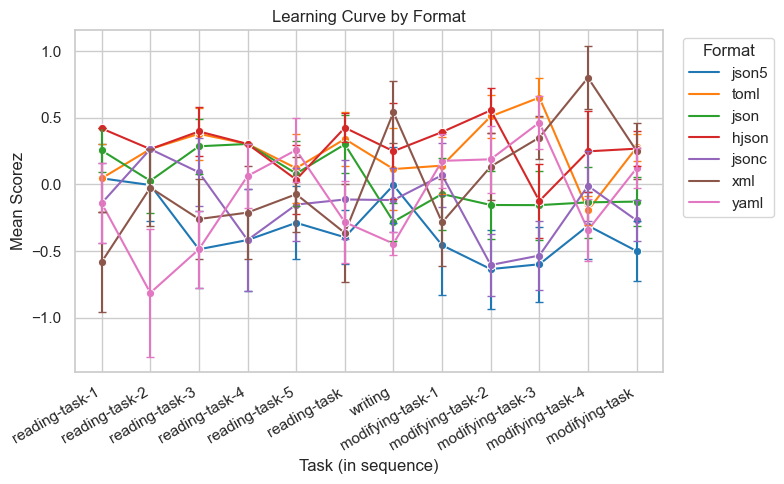

In [215]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional

def plot_learning_curve_by_format(
    total_score: pd.DataFrame,
    task_order: List[str],
    figsize: Tuple[float, float] = (8, 5),
    palette: Optional[List] = None
):
    """
    绘制各 format 在指定任务顺序下的学习曲线（Mean ± SEM）。

    参数
    ----
    total_score : pandas.DataFrame
      必须包含列 ['participantId','task','score','format']。
    task_order : List[str]
      指定所有 task 的顺序，例如：
        ['reading-task-1', ..., 'writing', 'modifying-task-1', ...]
    figsize : tuple
      图像大小，默认 (8,5)
    palette : list, optional
      seaborn 调色板；若 None 则自动用 tab10。

    返回
    ----
    ax : matplotlib.axes.Axes
      绘制好的坐标轴对象。
    """

    # 0) 复制一份，避免修改原表
    df = total_score.copy()

    # 1) 生成 part_no
    task2no = {t: i+1 for i, t in enumerate(task_order)}
    df['part_no'] = df['task'].map(task2no)
    missing = df[df['part_no'].isna()]['task'].unique()
    if len(missing) > 0:
        raise KeyError(f"下面这些 task 不在 task_order 里：{missing.tolist()}")

    # 2) 按 format × task × part_no 聚合出 mean ± SEM
    agg = (
        df
        .groupby(['format', 'task', 'part_no'], as_index=False)
        .agg(
            mean_score_z=('score_z', 'mean'),
            sem_score_z =('score_z', lambda x: x.std(ddof=1) / (len(x) ** 0.5))
        )
    )
    # 按 part_no 排序保证 x 轴有序
    agg = agg.sort_values('part_no')

    # 3) 开始画图
    plt.figure(figsize=figsize)
    sns.set_theme(style='whitegrid')

    if palette is None:
        palette = sns.color_palette("tab10", n_colors=agg['format'].nunique())

    ax = sns.lineplot(
        data=agg,
        x='task', y='mean_score_z',
        hue='format',
        marker='o',
        err_style='bars',
        ci=None,
        palette=palette
    )

    # 4) 手动加 SEM 误差条
    fmt_list = list(agg['format'].unique())
    # seaborn 画完后，会生成若干 Line2D 对象，每个 format 一条
    lines = ax.get_lines()[:len(fmt_list)]
    colors = [ln.get_color() for ln in lines]

    for i, fmt in enumerate(fmt_list):
        sub = agg[agg['format'] == fmt]
        ax.errorbar(
            x=sub['task'],
            y=sub['mean_score_z'],
            yerr=sub['sem_score_z'],
            fmt='none',
            capsize=3,
            color=colors[i]
        )

    # 5) 美化细节
    ax.set_xlabel('Task (in sequence)')
    ax.set_ylabel('Mean Scorez')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_title('Learning Curve by Format')
    ax.legend(title='Format', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    return ax

# 你的 total_score DataFrame，必须包含 ['participantId','task','score','format']。
# 定义任务顺序（例）：
task_order = [
    'reading-task-1','reading-task-2','reading-task-3','reading-task-4','reading-task-5','reading-task',
    'writing',
    'modifying-task-1','modifying-task-2','modifying-task-3','modifying-task-4','modifying-task'
]

# 调用函数
ax = plot_learning_curve_by_format(
    total_score=total_score,
    task_order=task_order
)
plt.show()


In [192]:
total_score=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/total_score_config.csv')
total_score

,participantId,task,score,score_z,format
0,67895b7d6400163124042af7,reading-task-config-1,1.000000,0.419314,jsonc
1,67895b7d6400163124042af7,reading-task-config-2,0.000000,-1.911066,jsonc
2,67895b7d6400163124042af7,reading-task-config-3,1.000000,0.321081,jsonc
3,67895b7d6400163124042af7,reading-task-config-4,0.000000,-1.108678,jsonc
4,67895b7d6400163124042af7,reading-task-config-5,0.000000,-2.223611,jsonc
...,...,...,...,...,...
1279,67f66486e35051403284eb5e,modifying-task,0.687352,0.132312,xml
1280,680ebf035ab59d342f31726e,modifying-task,0.967487,0.933454,hjson
1281,681374d36d7bd7ccb6f914f5,modifying-task,0.593061,-0.136519,json5
1282,68138e7f96395f4c5f3a0a87,modifying-task,0.389712,-0.716688,json


In [218]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings

# —— 1) 读取或准备你的 total_score DataFrame —— #
# total_score = pd.read_csv('...')  # 或者你已有的 DataFrame

# —— 2) 定义任务顺序并映射 part_no —— #
task_order = [
    'reading-task-1','reading-task-2','reading-task-3','reading-task-4','reading-task-5',
    'writing',
    'modifying-task-1','modifying-task-2','modifying-task-3','modifying-task-4'
]
task2no = {t: i+1 for i, t in enumerate(task_order)}
total_score['part_no'] = total_score['task'].map(task2no)

# 丢弃不在顺序表中的行
total_score = total_score.dropna(subset=['part_no'])
total_score['part_no'] = total_score['part_no'].astype(int)

# —— 3) 整体 Pearson 相关 —— #
r_all, p_all = pearsonr(total_score['part_no'], total_score['score_z'])
print(f"Overall order-score_z Pearson r = {r_all:.3f}, p = {p_all:.3f}")

# —— 4) 分格式 Pearson 相关 —— #
rows = []
for fmt, grp in total_score.groupby('format'):
    if len(grp['part_no']) >= 2:
        r, p = pearsonr(grp['part_no'], grp['score_z'])
    else:
        r, p = np.nan, np.nan
    rows.append({'format': fmt, 'r': r, 'p': p})
corr_df = pd.DataFrame(rows).sort_values('format').reset_index(drop=True)
print("\nPer-format Pearson correlations:")
print(corr_df)

# —— 5) 普通 OLS 回归 —— #
ols_model = smf.ols('score_z ~ part_no', data=total_score).fit()
print("\nOLS regression: score_z ~ part_no")
print(ols_model.summary())

# —— 6) 线性混合模型 —— #
# 忽略掉 ConvergenceWarning
warnings.filterwarnings("ignore", category=sm.tools.sm_exceptions.ConvergenceWarning)

mixed = smf.mixedlm('score_z ~ part_no', total_score,
                    groups=total_score['participantId'])
mixed_res = mixed.fit(reml=False)
print("\nMixed-effects model: score_z ~ part_no + (1 | participantId)")
print(mixed_res.summary())


Overall order-score_z Pearson r = 0.000, p = 1.000

Per-format Pearson correlations:
  format         r         p
0  hjson -0.063289  0.426574
1   json -0.163885  0.032720
2  json5 -0.120514  0.141832
3  jsonc -0.109554  0.182023
4   toml  0.016301  0.843052
5    xml  0.273854  0.001060
6   yaml  0.164158  0.044713

OLS regression: score_z ~ part_no
                            OLS Regression Results                            
Dep. Variable:                score_z   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                     0.000
Date:                Tue, 17 Jun 2025   Prob (F-statistic):               1.00
Time:                        11:23:16   Log-Likelihood:                -1518.3
No. Observations:                1070   AIC:                             3041.
Df Residuals:                    1068   BIC:                             3050.
Df Model:       

In [220]:
rows = []
for fmt, grp in total_score.groupby('format'):
    m = smf.ols('score ~ part_no', data=grp).fit()
    rows.append({
        'format': fmt,
        'slope':   m.params['part_no'],
        'pvalue':  m.pvalues['part_no'],
        'R2':      m.rsquared
    })

fmt_coef_df = pd.DataFrame(rows).sort_values('format')
print(fmt_coef_df.to_string(index=False))


format     slope       pvalue       R2
 hjson -0.045538 1.594769e-05 0.111502
  json -0.058825 4.951697e-08 0.162654
 json5 -0.057559 7.474785e-06 0.127198
 jsonc -0.054377 5.712106e-06 0.130237
  toml -0.036530 3.920289e-04 0.081687
   xml  0.002003 8.650979e-01 0.000210
  yaml -0.019629 1.172747e-01 0.016495


In [230]:
import numpy as np

summary = (
    total_score
    .groupby('part_no')
    .agg(
        mean_score=('score', 'mean'),
        sem_score =('score', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n         =('score', 'size')
    )
    .reset_index()
    .sort_values('part_no')
)

print(summary.to_string(index=False))


 part_no  mean_score  sem_score   n
       1    0.850467   0.034637 107
       2    0.785047   0.039899 107
       3    0.906542   0.028272 107
       4    0.551402   0.048307 107
       5    0.831776   0.036332 107
       6    0.785047   0.021852 107
       7    0.322040   0.025154 107
       8    0.716303   0.034004 107
       9    0.628063   0.033781 107
      10    0.656629   0.034090 107
      11    0.562277   0.034078 107
      12    0.640818   0.026280 107


In [231]:
education_config=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/4_education_config.csv')
education_tabular=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/4_education_tabular.csv')
education=pd.concat([education_config,education_tabular])
education

,participantId,education,format
0,67895b7d6400163124042af7,Bachelor's,jsonc
1,659960f32faa4ff4b116de92,High School,toml
2,5f7f239e9b204e05b6c36538,Master's,json5
3,67b8636acd5ed420cc098b64,Master's,toml
4,57ca4b09993b08000192297b,Bachelor's,xml
...,...,...,...
102,67ab650c320eccf6141d4010,Master's,jsonc
103,65fad673a546ab14baf2f8d3,Master's,json5
104,67f1c7bd6f1c4a3d8deae02f,Master's,toml
105,67adb27bd5f5776fcb16da62,Bachelor's,hjson


In [236]:
result_tabular=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/result_tabular.csv')
result_config=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/result_config.csv')
result=pd.concat([result_tabular,result_config])
result

,participantId,sum_score_z,format,task
0,56cb8858edf8da000b6df354,0.787108,hjson,user_study
1,57c357770e6a1f00015f6038,-0.008300,json,user_study
2,5b68c9eb87af310001584803,-1.165757,json5,user_study
3,5c6414540821d30001046198,0.519737,hjson,user_study
4,5d30dfa68b1523000134878f,1.282446,json,user_study
...,...,...,...,...
102,67f66486e35051403284eb5e,-1.785178,xml,user_study
103,680ebf035ab59d342f31726e,1.610701,hjson,user_study
104,681374d36d7bd7ccb6f914f5,2.473541,json5,user_study
105,68138e7f96395f4c5f3a0a87,-1.342113,json,user_study


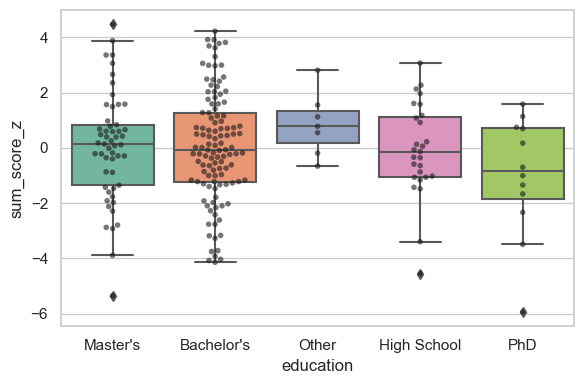

In [240]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, levene, shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1) 合并 df
df = result.merge(education[['participantId','education']],
                  on='participantId', how='left').dropna(subset=['education'])

# 2) 画图
plt.figure(figsize=(6,4))
ax = sns.boxplot(x='education', y='sum_score_z', data=df, palette='Set2')
sns.swarmplot(x='education', y='sum_score_z', data=df,
              color='k', alpha=0.6, size=4, ax=ax)

# 3) Tukey HSD
# 3) Tukey HSD
tukey = pairwise_tukeyhsd(
    endog=df['sum_score_z'],
    groups=df['education'],
    alpha=0.05
)

# 4) 手动把显著对画星号
import numpy as np

levels = df['education'].unique().tolist()
pos = {lev:i for i,lev in enumerate(levels)}

# 拿到每条箱线（box artist）最高点
box_coords = []
for i, patch in enumerate(ax.artists):
    # patch.get_y() 是 box 底部 y, patch.get_height() 是 box 高度
    box_coords.append(patch.get_y() + patch.get_height())

for row in tukey.summary().data[1:]:
    g1 = row[0]
    g2 = row[1]
    p_adj = float(row[3])   # 'p-adj' 在第 3 列
    reject = row[6]         # 'reject' 在第 6 列
    if reject == 'True':
        x1, x2 = pos[g1], pos[g2]
        y = max(box_coords[x1], box_coords[x2]) + 0.05
        stars = '***' if p_adj<0.001 else '**' if p_adj<0.01 else '*' if p_adj<0.05 else ''
        # 画横线——一个「┌─┐」型
        ax.plot([x1, x1, x2, x2],
                [y-0.01, y,   y,   y-0.01],
                lw=1.2, color='k')
        # 标星号
        ax.text((x1+x2)*0.5, y, stars,
                ha='center', va='bottom', color='k')

plt.tight_layout()
plt.show()




=== ANOVA test ===
F = 1.20, p = 0.311


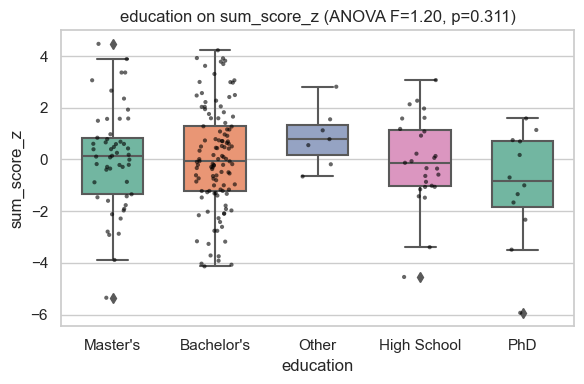

In [242]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import f_oneway, shapiro, levene, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = result.merge(education[['participantId','education']],
                  on='participantId', how='left').dropna(subset=['education'])

def plot_education_effect(
    df: pd.DataFrame,
    score_col: str = 'sum_score_z',
    group_col: str = 'education',
    test_method: str = 'anova',   # 'anova' 或 'kruskal'
    alpha: float = 0.05,
    figsize=(6,4),
    palette=None
):
    """
    比较 education 对 sum_score_z 的影响，打印检验结果，事后 Tukey，并画箱线＋星号。

    Parameters
    ----------
    df : DataFrame
        包含 [group_col, score_col]。
    score_col : str
        要比较的连续得分列名。
    group_col : str
        分类变量列名（education）。
    test_method : {'anova','kruskal'}
    alpha : float
        显著性水平。
    """

    # 1) 准备数据
    groups = [g[score_col].values for _, g in df.groupby(group_col)]
    levels = df[group_col].unique().tolist()

    # 2) 正式检验
    if test_method == 'anova':
        # 可选：先做正态性和方差齐性检验
        for lvl, series in df.groupby(group_col)[score_col]:
            if len(series) >= 3:
                p_s = shapiro(series)[1]
                if p_s < alpha:
                    print(f"Warning: group {lvl} Shapiro p={p_s:.3f}<α，ANOVA 可能不适用")
        p_l = levene(*groups)[1]
        if p_l < alpha:
            print(f"Warning: Levene p={p_l:.3f}<α，组内方差不齐")
        stat, pval = f_oneway(*groups)
        test_name = 'ANOVA'
        stat_chr = 'F'
    else:
        stat, pval = kruskal(*groups)
        test_name = 'Kruskal'
        stat_chr = 'H'

    # 3) 打印简洁结果
    print(f"\n=== {test_name} test ===")
    print(f"{stat_chr} = {stat:.2f}, p = {pval:.3f}")

    # 4) Tukey HSD 事后比较
    tukey = pairwise_tukeyhsd(
        endog=df[score_col],
        groups=df[group_col],
        alpha=alpha
    )
    # 把 summary 转成 DataFrame 方便处理
    tukey_df = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
    # 只保留 reject=True 的对
    sig_pairs = tukey_df[tukey_df['reject']=='True']

    # 5) 作图
    plt.figure(figsize=figsize)
    ax = sns.boxplot(
        x=group_col, y=score_col,
        data=df, palette=palette, width=0.6
    )
    sns.stripplot(
        x=group_col, y=score_col,
        data=df, color='black', size=3, alpha=0.6, ax=ax, jitter=0.2
    )
    ax.set_title(f"{group_col} on {score_col} ({test_name} {stat_chr}={stat:.2f}, p={pval:.3f})")

    # 6) 标注显著星号
    # 先拿每个箱顶 y 值
    boxers = ax.artists
    box_tops = []
    for art in boxers:
        # get_y 是下边界，get_height 是高度
        box_tops.append(art.get_y() + art.get_height())

    pos = {lvl:i for i,lvl in enumerate(levels)}
    for _, row in sig_pairs.iterrows():
        g1, g2 = row['group1'], row['group2']
        p_adj = float(row['p-adj'])
        # 星号
        stars = '***' if p_adj<0.001 else '**' if p_adj<0.01 else '*' if p_adj<0.05 else ''
        if stars:
            x1, x2 = pos[g1], pos[g2]
            y = max(box_tops[x1], box_tops[x2]) + 0.05
            # 画 ┌─┐
            ax.plot([x1, x1, x2, x2],
                    [y-0.01, y,   y,   y-0.01],
                    lw=1.2, c='k')
            ax.text((x1+x2)/2, y, stars,
                    ha='center', va='bottom', color='k')

    plt.tight_layout()
    plt.show()

# 调用示例
plot_education_effect(
    df=df,                # 包含 participantId, education, format, sum_score_z
    score_col='sum_score_z',
    group_col='education',
    test_method='anova',      # 或 'kruskal'
    alpha=0.05,
    palette=sns.color_palette("Set2", n_colors=4)
)


In [244]:
experience_config=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/4_experience_config.csv')
experience_tabular=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/4_experience_tabular.csv')
experience=pd.concat([experience_config,experience_tabular])
experience

,participantId,yoe,format
0,67895b7d6400163124042af7,0.67,jsonc
1,659960f32faa4ff4b116de92,0.00,toml
2,5f7f239e9b204e05b6c36538,0.00,json5
3,67b8636acd5ed420cc098b64,6.00,toml
4,57ca4b09993b08000192297b,10.00,xml
...,...,...,...
102,67ab650c320eccf6141d4010,0.83,jsonc
103,65fad673a546ab14baf2f8d3,2.00,json5
104,67f1c7bd6f1c4a3d8deae02f,4.00,toml
105,67adb27bd5f5776fcb16da62,0.50,hjson


In [254]:

package_config=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/4_packge_config.csv')
package_tabular=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/4_packge_tabular.csv')
package = pd.concat([package_config,package_tabular])



=== ANOVA test ===
F = 0.11, p = 0.979


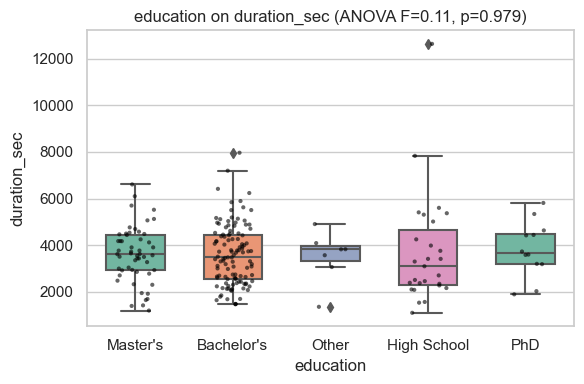

In [261]:
df = time_clean.merge(education[['participantId','education']],
                  on='participantId', how='left').dropna(subset=['education'])

plot_education_effect(
    df=df,                # 包含 participantId, education, format, sum_score_z
    score_col='duration_sec',
    group_col='education',
    test_method='anova',      # 或 'kruskal'
    alpha=0.05,
    palette=sns.color_palette("Set2", n_colors=4)
)

In [24]:
task_time=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/0_task_time.csv')
task_time

,participantId,task,duration_sec,format
0,67895b7d6400163124042af7,introduction,395.748,jsonc
1,67895b7d6400163124042af7,qualifications,10.282,jsonc
2,67895b7d6400163124042af7,consent,63.068,jsonc
3,67895b7d6400163124042af7,task,14.610,jsonc
4,67895b7d6400163124042af7,writing-task-NL,475.830,jsonc
...,...,...,...,...
6415,6675c40cdc52b37294f0514e,modifying-task-tabular-3_post-task-question,6.186,hjson
6416,6675c40cdc52b37294f0514e,modifying-task-tabular-4,209.509,hjson
6417,6675c40cdc52b37294f0514e,modifying-task-tabular-4_post-task-question,5.298,hjson
6418,6675c40cdc52b37294f0514e,$nasa-tlx.co.nasa-tlx,13.270,hjson


In [25]:
time_only=task_time[['participantId','task','duration_sec','format']][task_time['task'] != 'unqualified']

def clean_time_data(df):

    df_cleaned = df.copy()
    
    # 按participantId分组计算总duration
    total_durations = df_cleaned.groupby('participantId')['duration_sec'].sum().reset_index()
    
    # 获取每个participant的format
    participant_formats = df_cleaned.groupby('participantId')['format'].first().reset_index()
    
    # 合并total duration和format
    total_data = total_durations.merge(participant_formats, on='participantId')
    
    # 创建只包含total行的数据框
    total_rows = []
    for _, row in total_data.iterrows():
        total_row = {
            'participantId': row['participantId'],
            'task': 'total',
            'duration_sec': row['duration_sec'],
            'format': row['format']
        }
        total_rows.append(total_row)
    
    # 只返回total行，不包含原始数据
    result_df = pd.DataFrame(total_rows)
    
    return result_df

time_clean=clean_time_data(time_only)
time_clean

,participantId,task,duration_sec,format
0,56cb8858edf8da000b6df354,total,1651.245,hjson
1,5755c957eb80c4000741a9ce,total,1422.986,json5
2,5795af044a84da00014c5df1,total,1949.891,json
3,57c357770e6a1f00015f6038,total,1920.531,json
4,57ca4b09993b08000192297b,total,2118.831,xml
...,...,...,...,...
209,67f913a9b5c79e960807c7e3,total,3824.932,yaml
210,680ebf035ab59d342f31726e,total,5409.049,hjson
211,681374d36d7bd7ccb6f914f5,total,1645.963,json5
212,68138e7f96395f4c5f3a0a87,total,5339.369,json


In [2]:
import pandas as pd
time_norm_config=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/not_use/writing_norm_config.csv')
time_norm_config = time_norm_config[['participantId','task','normalized_time','format']]
time_norm_tabular=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/not_use/writing_norm_tabular.csv')
time_norm_tabular = time_norm_tabular[['participantId','task','normalized_time','format']]
time_norm=pd.concat([time_norm_config,time_norm_tabular])
time_norm['task'] = 'writing-task'
time_norm

,participantId,task,normalized_time,format
0,67895b7d6400163124042af7,writing-task,1289.395448,jsonc
1,659960f32faa4ff4b116de92,writing-task,502.076015,toml
2,5f7f239e9b204e05b6c36538,writing-task,483.794382,json5
3,67b8636acd5ed420cc098b64,writing-task,1614.758311,toml
4,57ca4b09993b08000192297b,writing-task,196.913772,xml
...,...,...,...,...
102,67ab650c320eccf6141d4010,writing-task,2811.811924,jsonc
103,65fad673a546ab14baf2f8d3,writing-task,790.859676,json5
104,67f1c7bd6f1c4a3d8deae02f,writing-task,550.434343,toml
105,67adb27bd5f5776fcb16da62,writing-task,804.830207,hjson


In [5]:
dc_config=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/3_dc_agg_result_config.csv')
dc_config

,participantId,format,task,difficulty,confidence
0,67895b7d6400163124042af7,jsonc,writing-task-config,7.00,4.00
1,659960f32faa4ff4b116de92,toml,writing-task-config,7.00,1.00
2,5f7f239e9b204e05b6c36538,json5,writing-task-config,7.00,1.00
3,67b8636acd5ed420cc098b64,toml,writing-task-config,7.00,1.00
4,57ca4b09993b08000192297b,xml,writing-task-config,4.00,4.00
...,...,...,...,...,...
316,681374d36d7bd7ccb6f914f5,json5,reading-task-config,1.20,6.80
317,68138e7f96395f4c5f3a0a87,json,modifying-task-config,4.75,2.25
318,68138e7f96395f4c5f3a0a87,json,reading-task-config,4.60,2.80
319,6818ca1523ece90f671e3601,json,modifying-task-config,2.75,5.25


In [19]:
total_result_config=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/total_score_config.csv')
total_result_tabular=pd.read_csv('/Users/shiyihe/Desktop/VIS_RESULT/total_score_tabular.csv')
total_result_config=total_result_config[total_result_config['task'] == 'writing']
total_result_tabular=total_result_tabular[total_result_tabular['task'] == 'writing']
total_result=pd.concat([total_result_config,total_result_tabular])
total_result


,participantId,task,score,score_z,format
642,670f9ddb0e32533c222c3031,writing,0.172414,-0.577760,json
643,671bdd06525adeea062a1d73,writing,0.403846,0.315885,json
644,66912d7bf9d35c08f6919958,writing,0.147059,-0.675665,json
645,6818ca1523ece90f671e3601,writing,0.166667,-0.599952,json
646,6680d2279263349cc005956a,writing,0.923077,2.320825,json
...,...,...,...,...,...
744,66bb6b7e0ccbed81f3ed30a8,writing,0.468182,0.515481,xml
745,6753746b1f8827e2bd586bf0,writing,0.279412,-0.116750,xml
746,669a84e18da4349ece0ea67c,writing,0.279412,-0.116750,xml
747,67ab57e88fd0774428bd1f32,writing,0.279412,-0.116750,xml


=== Time vs. Score Correlation ===
Pearson  r = -0.060, p = 0.379
Spearman r = -0.109, p = 0.110



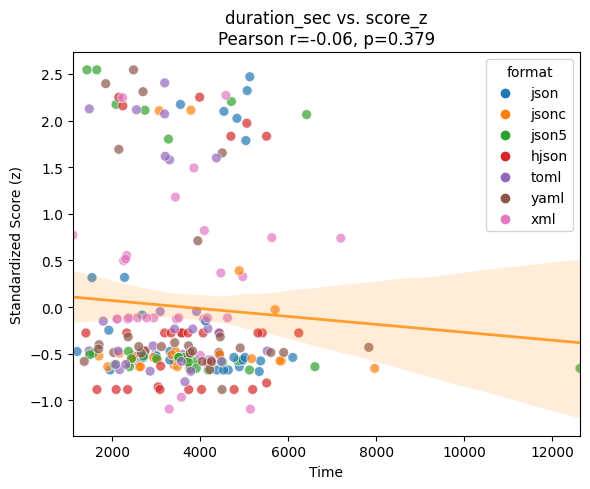

  format  pearson_r  pearson_p
0  hjson   0.079864   0.669325
1   json   0.203924   0.262932
2  json5  -0.189449   0.316015
3  jsonc   0.024828   0.896383
4   toml  -0.137187   0.469738
5    xml   0.022624   0.907265
6   yaml  -0.266355   0.140602


In [28]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

def compute_time_score_correlation(df,
                                   time_col='normalized_time',
                                   score_col='sum_score_z'):
    """
    计算 time_col 与 score_col 之间的 Pearson 和 Spearman 相关系数。
    """
    x = df[time_col]
    y = df[score_col]

    pear_r, pear_p = pearsonr(x, y)
    spear_r, spear_p = spearmanr(x, y)

    print("=== Time vs. Score Correlation ===")
    print(f"Pearson  r = {pear_r:.3f}, p = {pear_p:.3f}")
    print(f"Spearman r = {spear_r:.3f}, p = {spear_p:.3f}")
    print()
    return {
        'pearson_r': pear_r, 'pearson_p': pear_p,
        'spearman_r': spear_r, 'spearman_p': spear_p
    }


df = total_result.merge(time_clean[['participantId','duration_sec']],
                  on='participantId', how='left').dropna(subset=['duration_sec'])

# 调用示例
corr_res = compute_time_score_correlation(
    df=df,
    time_col='duration_sec',
    score_col='score_z'
)


import seaborn as sns
import matplotlib.pyplot as plt

def plot_time_vs_score(df,
                       time_col='duration_sec',
                       score_col='sum_score_z',
                       hue_col='format'):
    """
    画 normalized_time vs. score 的散点图并加回归线，
    如果提供 hue_col，就按不同类别染色。
    """
    plt.figure(figsize=(6,5))
    # 散点
    if hue_col and hue_col in df.columns:
        sns.scatterplot(data=df,
                        x=time_col, y=score_col,
                        hue=hue_col,
                        alpha=0.7,
                        s=50)
    else:
        sns.scatterplot(data=df,
                        x=time_col, y=score_col,
                        color='steelblue',
                        alpha=0.7,
                        s=50)

    # 回归线
    sns.regplot(data=df,
                x=time_col, y=score_col,
                scatter=False,
                color='darkorange',
                line_kws={'lw':2, 'alpha':0.8})

    # 标题里把 Pearson r, p 再标一下
    pear_r, pear_p = pearsonr(df[time_col], df[score_col])
    plt.title(
        f"{time_col} vs. {score_col}\n"
        f"Pearson r={pear_r:.2f}, p={pear_p:.3f}"
    )
    plt.xlabel("Time")
    plt.ylabel("Standardized Score (z)")
    plt.tight_layout()
    plt.show()

# 调用示例


plot_time_vs_score(
    df=df,
    time_col='duration_sec',
    score_col='score_z',
    hue_col='format'   # 如果不想分格式看，就传 None
)

def per_format_time_score(df,
                          time_col='duration_sec',
                          score_col='sum_score_z',
                          group_col='format'):
    records = []
    for fmt, sub in df.groupby(group_col):
        r, p = pearsonr(sub[time_col], sub[score_col])
        records.append({
            group_col: fmt,
            'pearson_r': r,
            'pearson_p': p
        })
    return pd.DataFrame(records)

fmt_corr = per_format_time_score(
    df=df,
    time_col='duration_sec',
    score_col='score_z',
    group_col='format'
)
print(fmt_corr)


In [22]:
total_result

,participantId,task,score,score_z,format
642,670f9ddb0e32533c222c3031,writing,0.172414,-0.577760,json
643,671bdd06525adeea062a1d73,writing,0.403846,0.315885,json
644,66912d7bf9d35c08f6919958,writing,0.147059,-0.675665,json
645,6818ca1523ece90f671e3601,writing,0.166667,-0.599952,json
646,6680d2279263349cc005956a,writing,0.923077,2.320825,json
...,...,...,...,...,...
744,66bb6b7e0ccbed81f3ed30a8,writing,0.468182,0.515481,xml
745,6753746b1f8827e2bd586bf0,writing,0.279412,-0.116750,xml
746,669a84e18da4349ece0ea67c,writing,0.279412,-0.116750,xml
747,67ab57e88fd0774428bd1f32,writing,0.279412,-0.116750,xml


In [27]:
time_clean

,participantId,task,duration_sec,format
0,56cb8858edf8da000b6df354,total,1651.245,hjson
1,5755c957eb80c4000741a9ce,total,1422.986,json5
2,5795af044a84da00014c5df1,total,1949.891,json
3,57c357770e6a1f00015f6038,total,1920.531,json
4,57ca4b09993b08000192297b,total,2118.831,xml
...,...,...,...,...
209,67f913a9b5c79e960807c7e3,total,3824.932,yaml
210,680ebf035ab59d342f31726e,total,5409.049,hjson
211,681374d36d7bd7ccb6f914f5,total,1645.963,json5
212,68138e7f96395f4c5f3a0a87,total,5339.369,json


In [ ]:
time_m=time_only[['participantId','task','duration_sec','format']]
time_m['task'] = 'modifying-task'
time_m